In [14]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
#!pip install pmdarima
from pmdarima import auto_arima
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pmd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

Master_File= '/Users/kellyxu/Documents/Uni/Capstone/nsw_clean_outputs/Final_master_daily_with_env.csv'
demanddaily= pd.read_csv(Master_File)
demanddaily

,DATE,demand_mw_sum,demand_mw_mean,demand_mw_max,forecast_mw_sum,forecast_mw_mean,forecast_mw_max,fcst_error_mean,fcst_abs_error_sum,fcst_ape_mean,...,irradiance,precipitation,rn_temp_c,wind_speed,rn_temp_c_max,wind_speed_max,irradiance_max,precipitation_max,cloud_cover_max,humidity_max
0,2010-01-01,374464.94,7801.352917,8883.98,371544.79,7740.516458,8828.45,-60.836458,5539.93,1.518815,...,6566.473,3.182,24.172708,1.937417,27.530,2.455,814.862,0.212,0.855,0.015
1,2010-01-02,384838.07,8017.459792,9294.07,380738.11,7932.043958,9196.87,-85.415833,5437.94,1.437769,...,7220.681,9.976,22.872292,2.290292,28.724,3.333,911.016,0.829,0.567,0.015
2,2010-01-03,355195.18,7399.899583,8247.61,356437.13,7425.773542,8293.91,25.873958,3057.55,0.881358,...,6975.007,2.934,19.881917,2.590208,23.360,3.273,795.897,0.298,0.544,0.011
3,2010-01-04,395602.57,8241.720208,9468.92,399296.80,8318.683333,9638.88,76.963125,4266.75,1.075147,...,8053.354,0.264,21.534125,2.396375,25.720,3.050,888.921,0.049,0.346,0.012
4,2010-01-05,423735.03,8827.813125,10687.29,425227.19,8858.899792,10702.59,31.086667,4014.62,0.952121,...,8012.107,3.389,23.808500,1.899917,28.832,2.818,1057.264,0.519,0.560,0.014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4090,2021-03-14,340444.05,7092.584375,8050.23,0.00,NaN,NaN,NaN,0.00,NaN,...,3158.443,18.285,16.482250,3.322542,19.337,4.702,684.718,2.823,0.917,0.012
4091,2021-03-15,332669.89,6930.622708,8226.74,0.00,NaN,NaN,NaN,0.00,NaN,...,6280.335,0.553,18.190708,2.210917,21.925,2.639,855.126,0.079,0.210,0.010
4092,2021-03-16,351858.01,7330.375208,8568.28,0.00,NaN,NaN,NaN,0.00,NaN,...,5050.232,4.470,19.493000,2.814458,22.209,3.544,756.230,0.338,0.946,0.012
4093,2021-03-17,356553.02,7428.187917,8518.35,0.00,NaN,NaN,NaN,0.00,NaN,...,2555.555,10.069,19.360833,3.025292,21.047,3.557,493.487,1.405,0.967,0.013


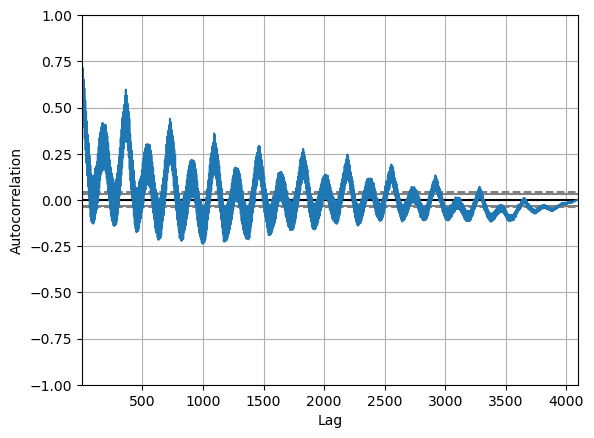

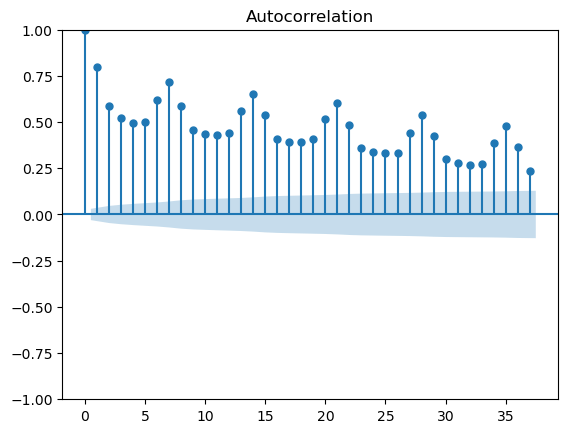

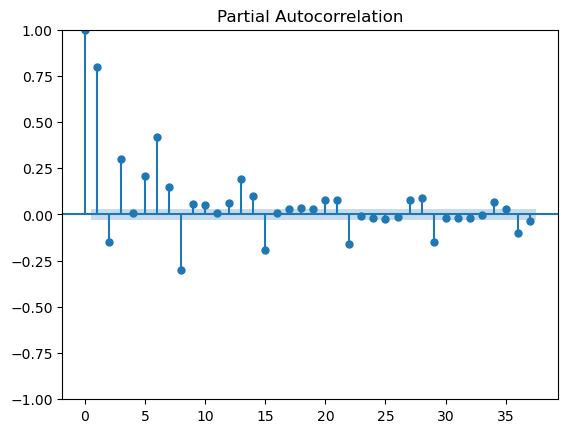

In [7]:
autocorrelation_plot(demanddaily['demand_mw_mean'])

#ACF plots

plot_acf(demanddaily['demand_mw_mean'])
plt.show()

plot_pacf(demanddaily['demand_mw_mean'])
plt.show()

### Comments
**Autocorrelation Plot**

- Decreasing correlation (d=1)

**Autocorrelation Function**
- Multiples of 7, could suggest seasonal MA =1

**Partial Autocorrelation Function**

- p,P = 1 (AR)

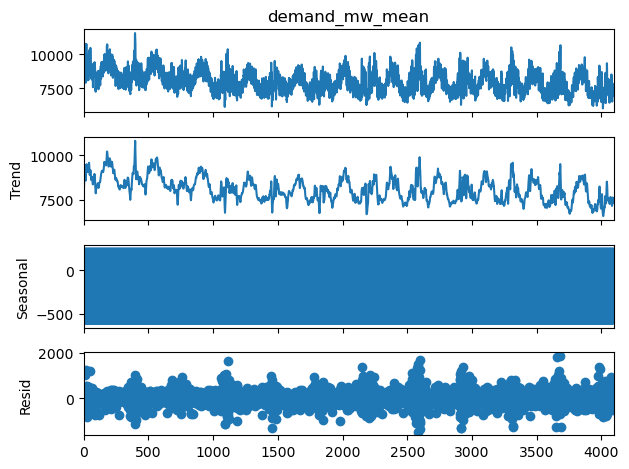

In [8]:
decomposition=seasonal_decompose(demanddaily['demand_mw_mean'],model='additive',period=7)
decomposition.plot()
plt.show()

In [5]:
demand_diff = demanddaily['demand_mw_mean'].diff(periods=7)

demand_diff = demand_diff.dropna()

dftest = adfuller(demand_diff, autolag='AIC')

print("1. ADF Statistic : ", dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags Used : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t", key, ": ", val)

1. ADF Statistic :  -11.127645417006676
2. P-Value :  3.342965713843763e-20
3. Num Of Lags Used :  30
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 4057
5. Critical Values :
	 1% :  -3.431962877092949
	 5% :  -2.862252680813649
	 10% :  -2.567149367114502


Diff. series is stationary. d=0 (non-seasonal differencing not required).  

In [6]:
import pmdarima as pmd
model=pmd.auto_arima(demanddaily['demand_mw_mean'],start_p=1,start_q=1,test='adf',m=7,seasonal=True,trace=True)


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[7] intercept   : AIC=60711.003, Time=4.36 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=66354.050, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=60757.485, Time=1.97 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=62136.085, Time=1.02 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=85382.683, Time=0.03 sec
 ARIMA(1,0,1)(0,0,1)[7] intercept   : AIC=61172.133, Time=1.47 sec
 ARIMA(1,0,1)(1,0,0)[7] intercept   : AIC=60470.453, Time=3.68 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=62011.812, Time=0.21 sec
 ARIMA(1,0,1)(2,0,0)[7] intercept   : AIC=60561.054, Time=8.14 sec
 ARIMA(1,0,1)(2,0,1)[7] intercept   : AIC=60737.642, Time=9.80 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=63151.305, Time=1.56 sec
 ARIMA(2,0,1)(1,0,0)[7] intercept   : AIC=inf, Time=3.56 sec
 ARIMA(1,0,2)(1,0,0)[7] intercept   : AIC=61061.476, Time=3.55 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=66335.580, Time=0.94 sec
 ARIMA(0,0,2)(1,0,0)[7] i

In [67]:
#Changed Q (seasonal MA to 1 as ACF graph showed multiples of 7)
sarima=SARIMAX(demanddaily['demand_mw_mean'],order=(1,0,1),seasonal_order=(1,0,1,7))

result = sarima.fit()

predicted = result.predict(start=0, end=len(demanddaily)-1)

print(predicted.head())
predicted=sarima.fit().predict();predicted


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.45476D+00    |proj g|=  1.16682D-01

At iterate    5    f=  7.38658D+00    |proj g|=  8.10778D-03

At iterate   10    f=  7.38405D+00    |proj g|=  3.31175D-03

At iterate   15    f=  7.35862D+00    |proj g|=  1.73102D-02

At iterate   20    f=  7.24596D+00    |proj g|=  2.08221D-02

At iterate   25    f=  7.24076D+00    |proj g|=  3.18695D-03

At iterate   30    f=  7.23989D+00    |proj g|=  3.84961D-04

At iterate   35    f=  7.23988D+00    |proj g|=  7.72731D-04

At iterate   40    f=  7.23927D+00    |proj g|=  5.31570D-03

At iterate   45    f=  7.23754D+00    |proj g|=  1.77178D-03


/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 This problem is unconstrained.



At iterate   50    f=  7.23749D+00    |proj g|=  7.89401D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50     64      1     0     0   7.894D-05   7.237D+00
  F =   7.2374884459655373     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 
0       0.000000
1    7277.701189
2    7499.723096
3    7032.580458
4    7877.316761
Name: predicted_mean, dtype: float64
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.45476D+00    |proj g|=  1.16682D-01

At iterat

/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


0          0.000000
1       7277.701189
2       7499.723096
3       7032.580458
4       7877.316761
           ...     
4090    7435.592394
4091    7726.679116
4092    7066.145407
4093    7372.573769
4094    7563.234673
Name: predicted_mean, Length: 4095, dtype: float64

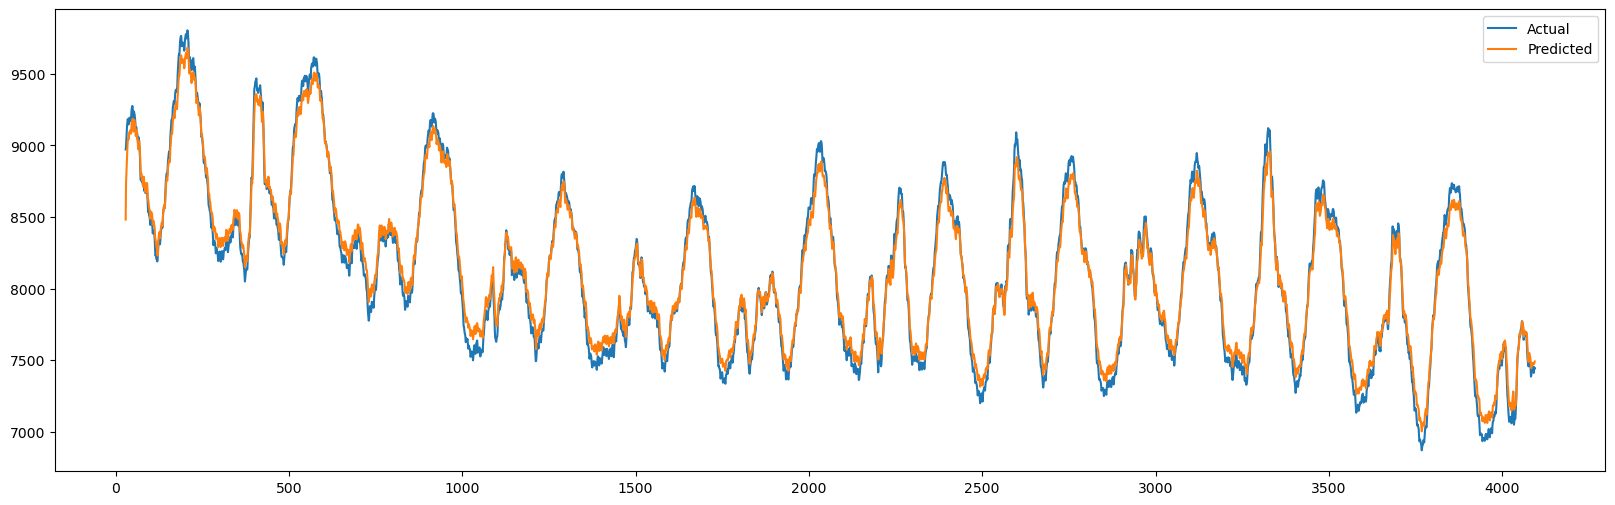

In [68]:
actual_smooth = demanddaily['demand_mw_mean'].rolling(30).mean()
predicted_smooth = predicted.rolling(30).mean()


plt.figure(figsize=(20,6))
plt.plot(actual_smooth,label='Actual')
plt.plot(predicted_smooth,label='Predicted')
plt.legend()

In [69]:
resid = demanddaily['demand_mw_mean'] - predicted
mae = resid.abs().mean()
print(mae)


rmse = np.sqrt((resid**2).mean())
print(rmse)

y_true = demanddaily['demand_mw_mean']
y_pred = predicted
mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
print(mape)

229.93161159541054
358.99662450027415
2.84509603201758


In [61]:
scaler = StandardScaler()
exog_scale = scaler.fit_transform(demanddaily[['rn_temp_c', 'precipitation', 'wind_speed','irradiance']])
print(exog_scale)
sarimax=SARIMAX(demanddaily['demand_mw_mean'],order=(1,0,1),seasonal_order=(1,0,1,7),exog=exog_scale)
print(results)

results = sarimax.fit()
predicted1 = results.predict(start=0, end=len(demanddaily)-1, exog=exog_scale)

[[ 1.43798012  0.11733    -0.43925051  0.6554846 ]
 [ 1.15496441  1.29805687  0.12983731  0.98250255]
 [ 0.50415523  0.07423016  0.61351828  0.85969787]
 ...
 [ 0.41951349  0.34117106  0.97517026 -0.10243648]
 [ 0.39074945  1.3142193   1.31518495 -1.34944686]
 [ 0.51975238  4.8902889   1.27520298 -1.43781011]]
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.46094D+00    |proj g|=  1.11863D-01


 This problem is unconstrained.



At iterate    5    f=  7.39513D+00    |proj g|=  7.51658D-03

At iterate   10    f=  7.39281D+00    |proj g|=  4.93507D-03

At iterate   15    f=  7.36639D+00    |proj g|=  3.37107D-02

At iterate   20    f=  7.26091D+00    |proj g|=  8.59227D-04

At iterate   25    f=  7.23258D+00    |proj g|=  6.44020D-02

At iterate   30    f=  7.22616D+00    |proj g|=  2.99860D-03

At iterate   35    f=  7.22297D+00    |proj g|=  3.87644D-02

At iterate   40    f=  7.18214D+00    |proj g|=  3.91308D-02

At iterate   45    f=  7.17775D+00    |proj g|=  1.16209D-03

At iterate   50    f=  7.17726D+00    |proj g|=  2.95554D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


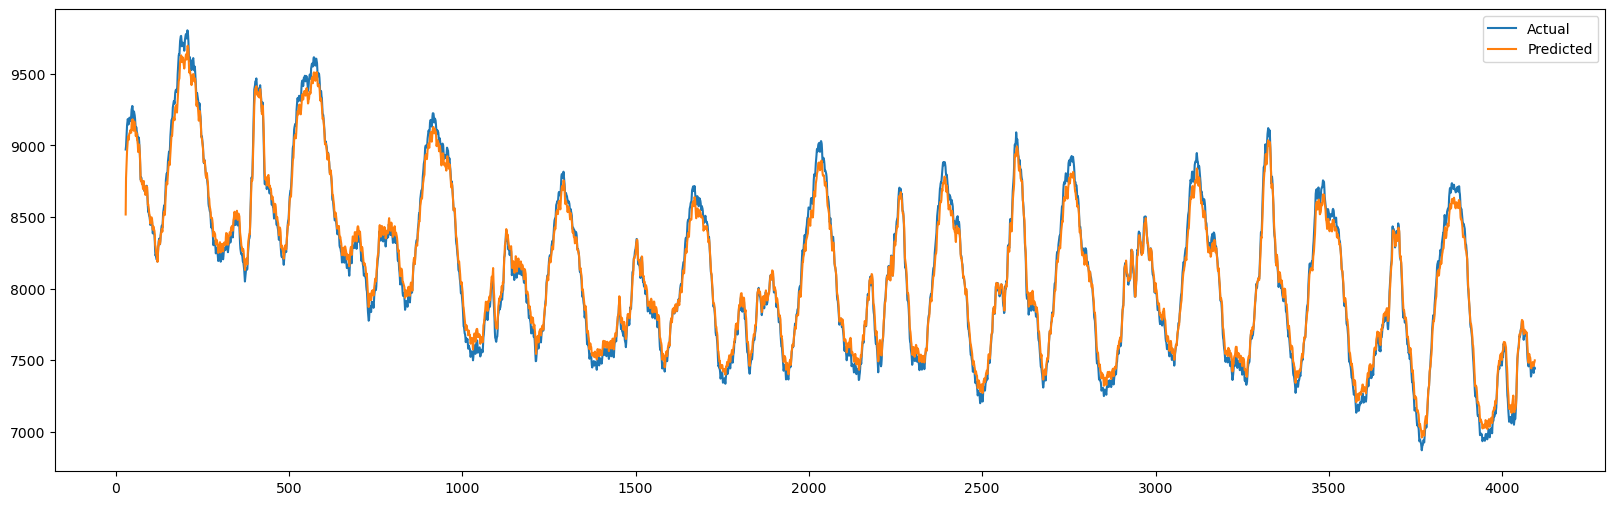

In [62]:
actual_smooth = demanddaily['demand_mw_mean'].rolling(30).mean()
predicted_smooth1 = predicted1.rolling(30).mean()

plt.figure(figsize=(20,6))
plt.plot(actual_smooth,label='Actual')
plt.plot(predicted_smooth1,label='Predicted')
plt.legend()

In [65]:
resid1 = demanddaily['demand_mw_mean'] - predicted1
mae1 = resid1.abs().mean()
print(mae1)
rmse1 = np.sqrt((resid1**2).mean())
print(rmse1)
y_true = demanddaily['demand_mw_mean']
y_pred = predicted1
mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
print(mape)

220.5577785444538
338.2203854196394
2.7295127740918024


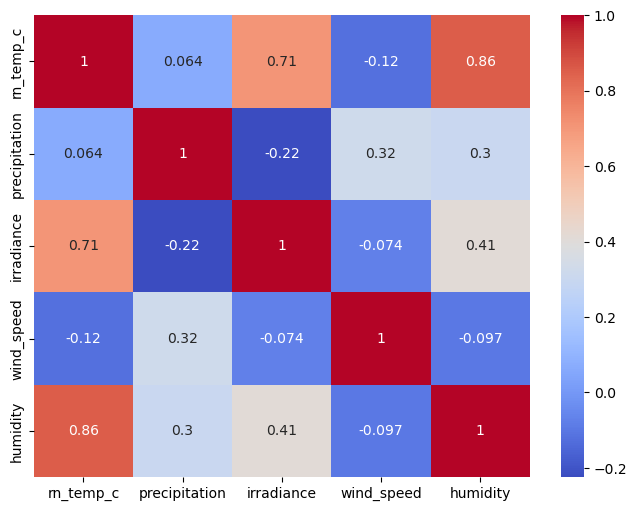

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

exog = demanddaily[['rn_temp_c', 'precipitation', 'irradiance', 'wind_speed', 'humidity']]
corr_matrix = exog.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()